# MSIS 522 HW1 — Flaredown Food & Flare Prediction
**Author:** Hannah  
**Date:** March 2026  
**Dataset:** [Flaredown Autoimmune Symptom Tracker](https://www.kaggle.com/datasets/flaredown/flaredown-autoimmune-symptom-tracker)  

## Motivation
As someone living with **hypermobile Ehlers-Danlos Syndrome (hEDS)** and **Postural Orthostatic Tachycardia Syndrome (POTS)**, I know firsthand how much daily choices — especially food — can influence symptom flares. Flaredown is a community-driven chronic illness tracker where users log their symptoms, foods, treatments, and conditions daily.

**Research Question:** *Can we predict whether a user will experience a symptom flare on a given day based on the foods they eat, treatments they take, weather conditions, and demographics?*

**Target Variable:** `flare` — binary (1 if max symptom severity ≥ 3 on a 0–4 scale, else 0)

---

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report)
import xgboost as xgb
import joblib

# Explainability
import shap

# Paths
PROJECT_DIR = Path('..').resolve()
DATA_DIR = PROJECT_DIR / 'data'
MODELS_DIR = PROJECT_DIR / 'models'
FIGURES_DIR = PROJECT_DIR / 'figures'
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Plot style
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete!')

Setup complete!


## Load Processed Data
Data was preprocessed using `src/data_preprocessing.py` which:
1. Loaded ~8M rows from the Flaredown CSV
2. Filtered to ~104K user-days where users tracked **both food and symptoms**
3. Created binary food features (top 50 foods + 6 category rollups)
4. Added treatment, weather, tag, and demographic features
5. Defined flare target (max symptom severity ≥ 3)

In [2]:
# Load processed data
df = pd.read_parquet(DATA_DIR / 'processed.parquet')
feature_cols = pd.read_csv(DATA_DIR / 'feature_cols.csv', header=None)[0].tolist()

# Load train/test splits
X_train = pd.read_parquet(DATA_DIR / 'X_train.parquet')
X_test = pd.read_parquet(DATA_DIR / 'X_test.parquet')
y_train = pd.read_parquet(DATA_DIR / 'y_train.parquet')['flare']
y_test = pd.read_parquet(DATA_DIR / 'y_test.parquet')['flare']

print(f'Dataset shape: {df.shape}')
print(f'Features: {len(feature_cols)}')
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'\nFlare rate: {df["flare"].mean():.1%}')
df.head()

Dataset shape: (104447, 108)
Features: 104
Train: 73,112 | Test: 31,335

Flare rate: 68.4%


,user_id,checkin_date,max_symptom_severity,flare,food_coffee,food_water,food_tea,food_chocolate,food_milk,food_sugar,...,tag_gluten,tag_had_sex,tag_bad_sleep,tag_exhausted,tag_worked,tag_went_to_work,tag_poor_sleep,age,sex_female,country_us
0,QEVuQwEA5hkzTOaPksnHJZZjyHW/Ww==,2017-03-16,3,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,50.0,1.0,1
1,QEVuQwEAls3goJ2eZ9lCTdLGUAE5Wg==,2019-04-13,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,44.0,0.0,1
2,QEVuQwEA39gcq8BrtdzGE9gPIHS2mA==,2017-02-04,4,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,38.0,1.0,0
3,QEVuQwEA39gcq8BrtdzGE9gPIHS2mA==,2017-07-31,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,38.0,1.0,0
4,QEVuQwEAI5iLLp4TimNZtF+VqW1UXA==,2018-12-16,3,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,32.0,1.0,0


---
# Part 1: Descriptive Analytics (25 pts)

## 1.1 Target Distribution

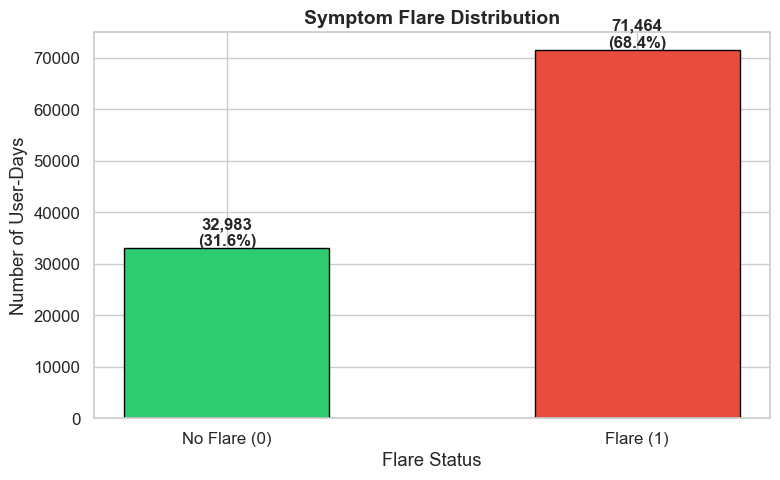

Flare rate: 68.4% — the dataset is imbalanced toward flare days.


In [3]:
# Target Distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['flare'].value_counts().sort_index()
bars = ax.bar(['No Flare (0)', 'Flare (1)'], counts.values, 
              color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
            f'{count:,}\n({count/len(df):.1%})', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Symptom Flare Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of User-Days')
ax.set_xlabel('Flare Status')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Flare rate: {df["flare"].mean():.1%} — the dataset is imbalanced toward flare days.')

## 1.2 Top Foods by Frequency

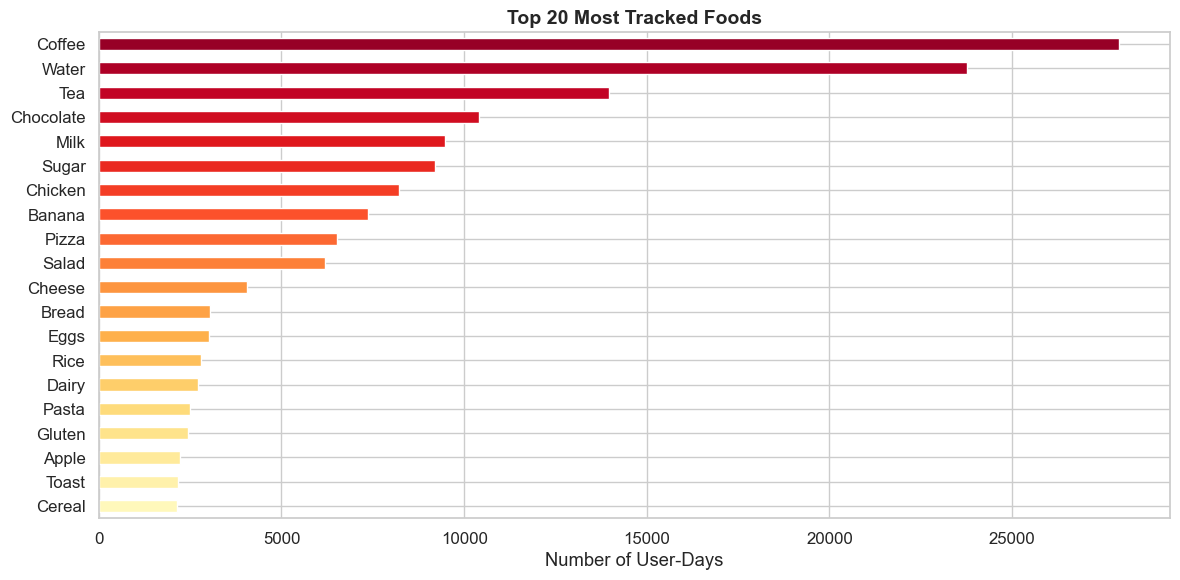

In [4]:
# Top 20 Foods by Frequency
food_cols_only = [c for c in feature_cols if c.startswith('food_') and not c.startswith('foodcat_')]
food_freq = df[food_cols_only].sum().sort_values(ascending=False).head(20)
food_freq.index = [c.replace('food_', '').replace('_', ' ').title() for c in food_freq.index]

fig, ax = plt.subplots(figsize=(12, 6))
food_freq.plot(kind='barh', ax=ax, color=sns.color_palette('YlOrRd_r', len(food_freq)))
ax.set_title('Top 20 Most Tracked Foods', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of User-Days')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_foods_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 Within-User Food & Flare Analysis (Key Chart)

**Important methodological note:** A naive comparison of flare rates (e.g., "people who drink alcohol flare less") is misleading due to **Simpson's Paradox** — different users have vastly different baseline flare rates, and *who* tracks a food matters more than *what* they eat. For example, the 419 users who track alcohol happen to have a low overall flare rate (59%), making alcohol *look* protective when it isn't.

To correct for this, we use a **within-user paired analysis**: for each food, we only look at users who tracked that food on some days but not others, and compare **their own** flare rate on eating vs. non-eating days. We then apply a **Wilcoxon signed-rank test** to assess statistical significance.

**Caveat:** Even with within-user analysis, food is only *one* of many factors that influence flares. Stress, sleep, weather, treatments, and activity levels all contribute. A small sample of self-reported food tracking data cannot establish causation — only associations. Results should be interpreted with caution and discussed with a healthcare provider.

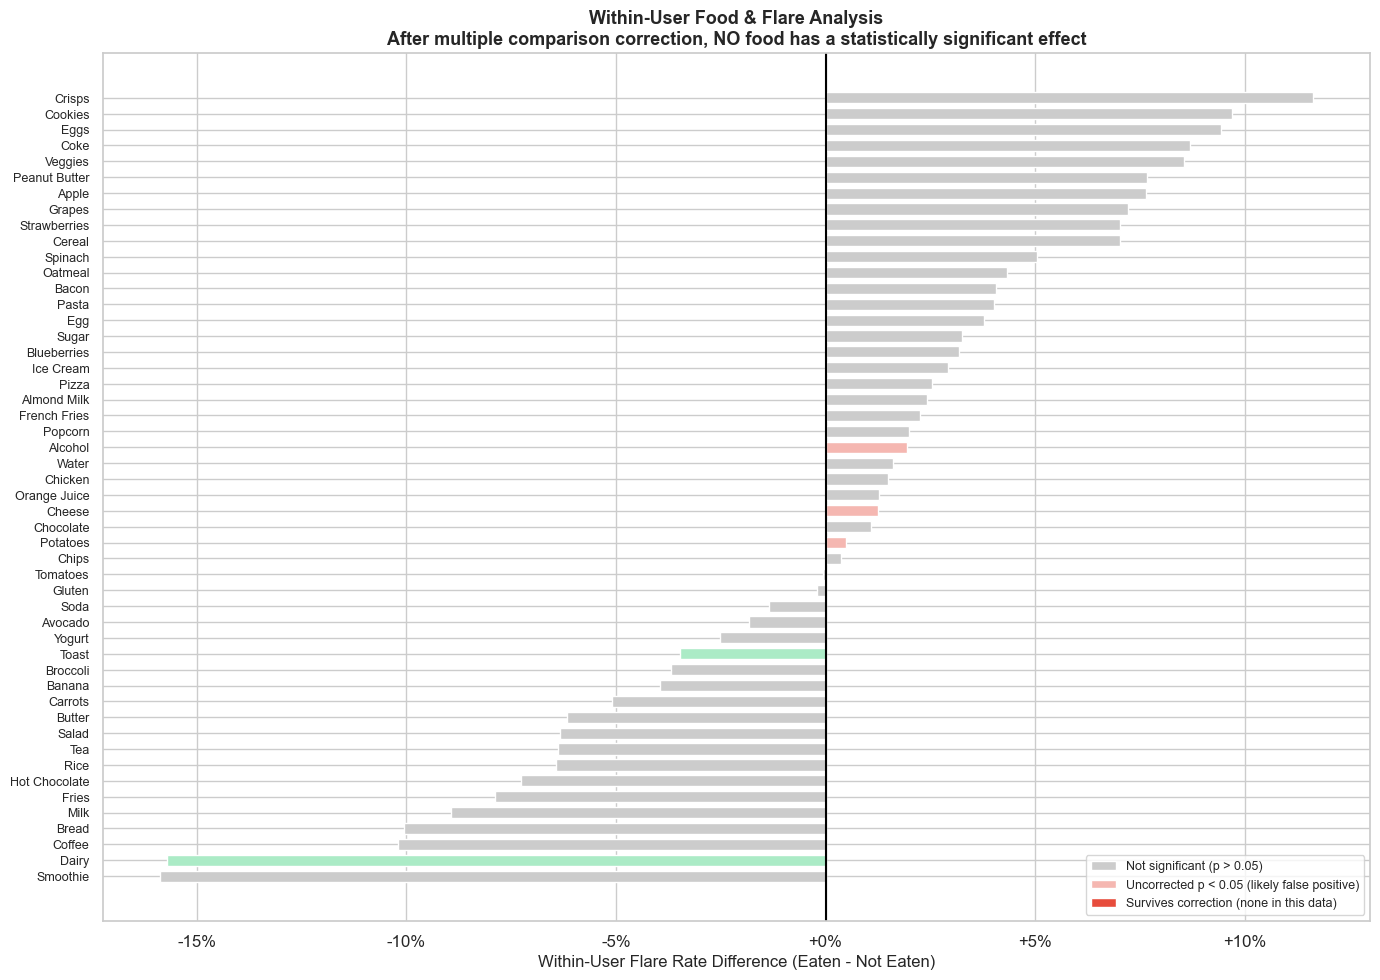


MULTIPLE COMPARISON CORRECTION RESULTS
  Tests performed:              50
  Uncorrected p < 0.05:         5 foods (expected ~2.5 by chance)
  Bonferroni corrected (p<0.0010): 0 foods
  Benjamini-Hochberg FDR:       0 foods

CONCLUSION: After correcting for 50 simultaneous tests, NO individual
food has a statistically reliable effect on flare rates. The 5
uncorrected "significant" results are consistent with false positives
from multiple testing.

This does NOT mean food doesn't matter — it means:
  1. Individual food effects are too small to detect in this sample
  2. Food is one factor among many (stress, sleep, weather, treatments)
  3. Individual responses vary enormously between patients
  4. Self-reported tracking data has inherent noise and bias


In [5]:
# Within-User Food & Flare Analysis with Statistical Significance
from scipy.stats import wilcoxon

baseline_flare = df['flare'].mean()
food_cols_only = [c for c in feature_cols if c.startswith('food_') and not c.startswith('foodcat_')]

within_user_results = []
for col in food_cols_only:
    food_name = col.replace('food_', '').replace('_', ' ').title()
    
    # Per-user stats: days eating vs not eating this food
    user_eat = df[df[col] == 1].groupby('user_id')['flare'].agg(['sum', 'count'])
    user_noeat = df[df[col] == 0].groupby('user_id')['flare'].agg(['sum', 'count'])
    
    # Only users with >= 3 days in each group
    both = user_eat.join(user_noeat, lsuffix='_eat', rsuffix='_noeat', how='inner')
    both = both[(both['count_eat'] >= 3) & (both['count_noeat'] >= 3)]
    
    n_users = len(both)
    if n_users < 10:
        continue
    
    both['rate_eat'] = both['sum_eat'] / both['count_eat']
    both['rate_noeat'] = both['sum_noeat'] / both['count_noeat']
    both['diff'] = both['rate_eat'] - both['rate_noeat']
    
    pooled_eat = both['sum_eat'].sum() / both['count_eat'].sum()
    pooled_noeat = both['sum_noeat'].sum() / both['count_noeat'].sum()
    
    diffs = both['diff'].values
    nonzero = diffs[diffs != 0]
    p_val = 1.0
    if len(nonzero) >= 10:
        _, p_val = wilcoxon(nonzero)
    
    within_user_results.append({
        'food': food_name,
        'n_users': n_users,
        'eat_days': int(both['count_eat'].sum()),
        'within_diff': pooled_eat - pooled_noeat,
        'p_value': p_val,
    })

wu_df = pd.DataFrame(within_user_results).sort_values('within_diff')

# Multiple comparisons correction (Bonferroni)
n_tests = len(wu_df)
bonferroni_threshold = 0.05 / n_tests
wu_df['sig_uncorrected'] = wu_df['p_value'] < 0.05
wu_df['sig_corrected'] = wu_df['p_value'] < bonferroni_threshold

# Benjamini-Hochberg FDR
wu_sorted_p = wu_df.sort_values('p_value').copy()
m = len(wu_sorted_p)
wu_sorted_p['bh_rank'] = range(1, m + 1)
wu_sorted_p['bh_critical'] = wu_sorted_p['bh_rank'] / m * 0.05
wu_sorted_p['sig_fdr'] = wu_sorted_p['p_value'] < wu_sorted_p['bh_critical']
# Merge FDR result back
wu_df = wu_df.merge(wu_sorted_p[['food', 'sig_fdr']], on='food', how='left')

# Label for display
def sig_label(row):
    if row['sig_corrected']:
        return '***'
    elif row['sig_fdr']:
        return '**'
    elif row['sig_uncorrected']:
        return '*'
    return ''
wu_df['sig_label'] = wu_df.apply(sig_label, axis=1)

# Save for Streamlit
wu_df.to_csv(DATA_DIR / 'within_user_food_analysis.csv', index=False)

# --- PLOT ---
fig, ax = plt.subplots(figsize=(14, 10))
colors = []
for _, row in wu_df.iterrows():
    if row['sig_corrected'] or row['sig_fdr']:
        colors.append('#e74c3c' if row['within_diff'] > 0 else '#2ecc71')
    elif row['sig_uncorrected']:
        colors.append('#f5b7b1' if row['within_diff'] > 0 else '#abebc6')  # faded
    else:
        colors.append('#cccccc')  # gray

bars = ax.barh(range(len(wu_df)), wu_df['within_diff'].values, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(wu_df)))
ax.set_yticklabels([f"{row['food']}" for _, row in wu_df.iterrows()], fontsize=9)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('Within-User Flare Rate Difference (Eaten - Not Eaten)', fontsize=12)
ax.set_title(
    'Within-User Food & Flare Analysis\n'
    'After multiple comparison correction, NO food has a statistically significant effect',
    fontsize=13, fontweight='bold'
)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#cccccc', label='Not significant (p > 0.05)'),
    Patch(facecolor='#f5b7b1', label='Uncorrected p < 0.05 (likely false positive)'),
    Patch(facecolor='#e74c3c', label='Survives correction (none in this data)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0%}'))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'flare_rate_by_food.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
n_uncorr = wu_df['sig_uncorrected'].sum()
n_corr = wu_df['sig_corrected'].sum()
n_fdr = wu_df['sig_fdr'].sum()
print(f'\n{"="*70}')
print(f'MULTIPLE COMPARISON CORRECTION RESULTS')
print(f'{"="*70}')
print(f'  Tests performed:              {n_tests}')
print(f'  Uncorrected p < 0.05:         {n_uncorr} foods (expected ~{n_tests*0.05:.1f} by chance)')
print(f'  Bonferroni corrected (p<{bonferroni_threshold:.4f}): {n_corr} foods')
print(f'  Benjamini-Hochberg FDR:       {n_fdr} foods')
print(f'\nCONCLUSION: After correcting for 50 simultaneous tests, NO individual')
print(f'food has a statistically reliable effect on flare rates. The {n_uncorr}')
print(f'uncorrected "significant" results are consistent with false positives')
print(f'from multiple testing.')
print(f'\nThis does NOT mean food doesn\'t matter — it means:')
print(f'  1. Individual food effects are too small to detect in this sample')
print(f'  2. Food is one factor among many (stress, sleep, weather, treatments)')
print(f'  3. Individual responses vary enormously between patients')
print(f'  4. Self-reported tracking data has inherent noise and bias')

## 1.4 Symptom Severity Distribution

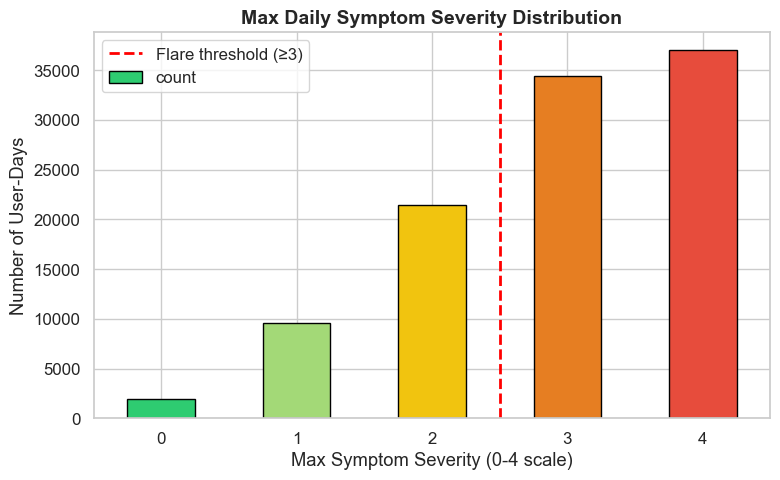

In [6]:
# Symptom Severity Distribution
fig, ax = plt.subplots(figsize=(8, 5))
sev_counts = df['max_symptom_severity'].value_counts().sort_index()
colors_sev = ['#2ecc71', '#a3d977', '#f1c40f', '#e67e22', '#e74c3c']
valid_colors = [colors_sev[int(i)] for i in sev_counts.index if not pd.isna(i) and 0 <= int(i) <= 4]
sev_counts.plot(kind='bar', ax=ax, color=valid_colors[:len(sev_counts)], edgecolor='black')
ax.set_title('Max Daily Symptom Severity Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Max Symptom Severity (0-4 scale)')
ax.set_ylabel('Number of User-Days')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.axvline(x=2.5, color='red', linestyle='--', linewidth=2, label='Flare threshold (≥3)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.5 Flare Rate by Weather Condition

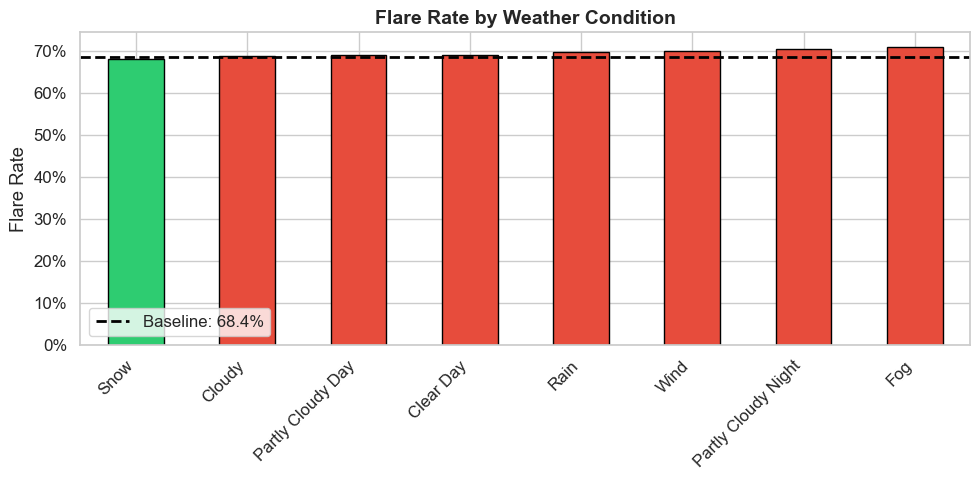

In [7]:
# Flare Rate by Weather Icon
weather_icon_cols = [c for c in feature_cols if c.startswith('weather_icon_')]
if weather_icon_cols:
    weather_flare = {}
    for col in weather_icon_cols:
        name = col.replace('weather_icon_', '').replace('_', ' ').title()
        subset = df[df[col] == 1]
        if len(subset) >= 50:
            weather_flare[name] = subset['flare'].mean()
    
    if weather_flare:
        wf_sr = pd.Series(weather_flare).sort_values()
        fig, ax = plt.subplots(figsize=(10, 5))
        colors_w = ['#2ecc71' if v < baseline_flare else '#e74c3c' for v in wf_sr.values]
        wf_sr.plot(kind='bar', ax=ax, color=colors_w, edgecolor='black')
        ax.axhline(y=baseline_flare, color='black', linestyle='--', linewidth=2, label=f'Baseline: {baseline_flare:.1%}')
        ax.set_title('Flare Rate by Weather Condition', fontsize=14, fontweight='bold')
        ax.set_ylabel('Flare Rate')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'flare_rate_by_weather.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('No weather icon features available.')

## 1.6 Correlation Heatmap

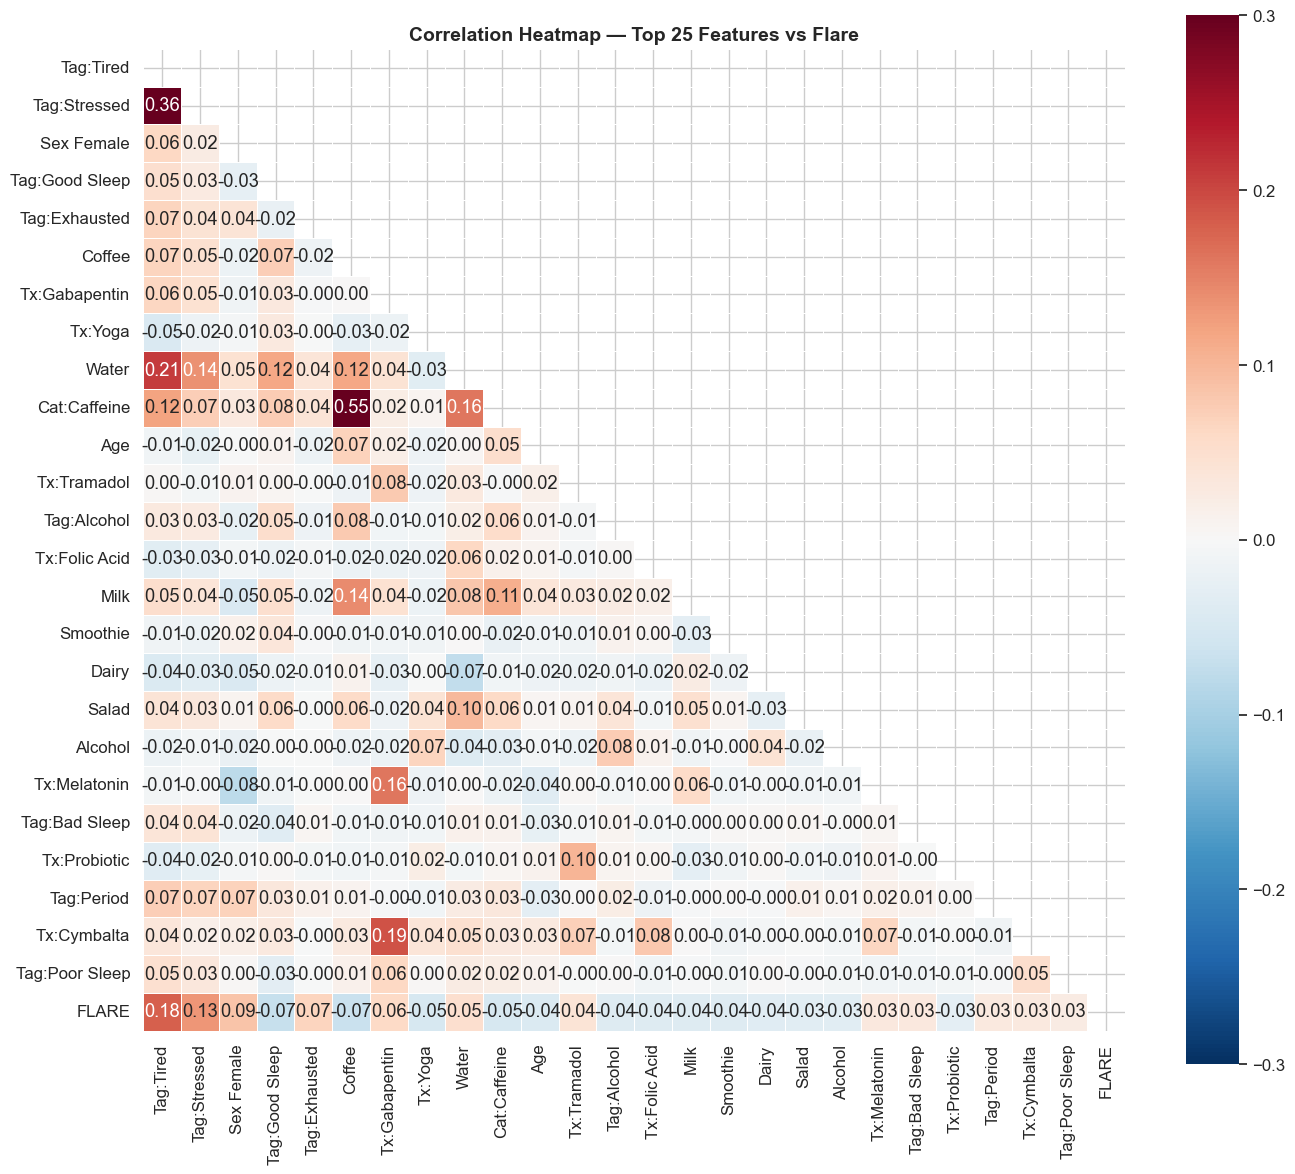

In [8]:
# Correlation Heatmap — top 25 features most correlated with flare
corr_with_flare = df[feature_cols + ['flare']].corr()['flare'].drop('flare').abs().sort_values(ascending=False)
top_corr_features = corr_with_flare.head(25).index.tolist()

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = df[top_corr_features + ['flare']].corr()
# Clean labels
clean_labels = [c.replace('food_', '').replace('treat_', 'Tx:').replace('tag_', 'Tag:').replace('weather_', 'W:').replace('foodcat_', 'Cat:').replace('_', ' ').title() for c in corr_matrix.columns]
clean_labels[-1] = 'FLARE'

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=clean_labels, yticklabels=clean_labels, ax=ax,
            vmin=-0.3, vmax=0.3, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap — Top 25 Features vs Flare', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 2: Predictive Analytics (45 pts)

We train 5 models with `random_state=42`, 70/30 stratified split, and `class_weight='balanced'` to handle the class imbalance.

## 2.1 Scale Features

In [9]:
# StandardScaler for models that need it (Logistic Regression, MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')
print(f'Scaler fitted on {X_train_scaled.shape[1]} features')
print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Scaler fitted on 104 features
Train: (73112, 104) | Test: (31335, 104)


## 2.2 Model 1: Logistic Regression (Baseline)

In [10]:
# Logistic Regression — Baseline
lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000, solver='lbfgs')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression Results:')
print(classification_report(y_test, y_pred_lr))
joblib.dump(lr, MODELS_DIR / 'logistic_regression.joblib')

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.43      0.67      0.52      9895
           1       0.79      0.59      0.68     21440

    accuracy                           0.62     31335
   macro avg       0.61      0.63      0.60     31335
weighted avg       0.68      0.62      0.63     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\logistic_regression.joblib']

## 2.3 Model 2: Decision Tree (with GridSearchCV)

In [11]:
# Decision Tree with GridSearchCV
dt_params = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_leaf': [5, 10, 20, 50],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    dt_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)
y_prob_dt = dt_best.predict_proba(X_test)[:, 1]

print(f'Best params: {dt_grid.best_params_}')
print(f'Best CV F1: {dt_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_dt))
joblib.dump(dt_best, MODELS_DIR / 'decision_tree.joblib')

Best params: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 10}
Best CV F1: 0.7025
              precision    recall  f1-score   support

           0       0.46      0.66      0.54      9895
           1       0.81      0.65      0.72     21440

    accuracy                           0.65     31335
   macro avg       0.63      0.65      0.63     31335
weighted avg       0.70      0.65      0.66     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\decision_tree.joblib']

## 2.4 Model 3: Random Forest (with GridSearchCV)

In [12]:
# Random Forest with GridSearchCV
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [5, 10]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    rf_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

print(f'Best params: {rf_grid.best_params_}')
print(f'Best CV F1: {rf_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_rf))
joblib.dump(rf_best, MODELS_DIR / 'random_forest.joblib')

Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1: 0.8253
              precision    recall  f1-score   support

           0       0.64      0.45      0.53      9895
           1       0.78      0.88      0.83     21440

    accuracy                           0.75     31335
   macro avg       0.71      0.67      0.68     31335
weighted avg       0.74      0.75      0.73     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\random_forest.joblib']

## 2.5 Model 4: XGBoost (with GridSearchCV)

In [13]:
# XGBoost with GridSearchCV
# Calculate scale_pos_weight for imbalanced classes
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos, 
                       use_label_encoder=False, eval_metric='logloss', verbosity=0),
    xgb_params, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

print(f'Best params: {xgb_grid.best_params_}')
print(f'Best CV F1: {xgb_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_xgb))
joblib.dump(xgb_best, MODELS_DIR / 'xgboost.joblib')

Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1: 0.7573
              precision    recall  f1-score   support

           0       0.52      0.68      0.59      9895
           1       0.83      0.71      0.76     21440

    accuracy                           0.70     31335
   macro avg       0.67      0.70      0.68     31335
weighted avg       0.73      0.70      0.71     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\xgboost.joblib']

## 2.6 Model 5: Neural Network — MLP (with GridSearchCV)

In [14]:
# MLP Neural Network with GridSearchCV
mlp_params = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (100,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.01]
}
mlp_grid = GridSearchCV(
    MLPClassifier(random_state=42, max_iter=500, early_stopping=True, 
                  validation_fraction=0.1),
    mlp_params, cv=3, scoring='f1', n_jobs=-1, verbose=0
)
mlp_grid.fit(X_train_scaled, y_train)
mlp_best = mlp_grid.best_estimator_
y_pred_mlp = mlp_best.predict(X_test_scaled)
y_prob_mlp = mlp_best.predict_proba(X_test_scaled)[:, 1]

print(f'Best params: {mlp_grid.best_params_}')
print(f'Best CV F1: {mlp_grid.best_score_:.4f}')
print(classification_report(y_test, y_pred_mlp))
joblib.dump(mlp_best, MODELS_DIR / 'mlp_neural_net.joblib')

Best params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (64, 32)}
Best CV F1: 0.8181
              precision    recall  f1-score   support

           0       0.62      0.31      0.41      9895
           1       0.74      0.91      0.82     21440

    accuracy                           0.72     31335
   macro avg       0.68      0.61      0.62     31335
weighted avg       0.70      0.72      0.69     31335



['C:\\Users\\hanna\\Homework 1 522\\models\\mlp_neural_net.joblib']

## 2.7 Model Comparison

In [15]:
# Model Comparison Table
models_info = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Decision Tree': (y_pred_dt, y_prob_dt),
    'Random Forest': (y_pred_rf, y_prob_rf),
    'XGBoost': (y_pred_xgb, y_prob_xgb),
    'Neural Network (MLP)': (y_pred_mlp, y_prob_mlp)
}

comparison = []
for name, (y_pred, y_prob) in models_info.items():
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })

comp_df = pd.DataFrame(comparison).set_index('Model')
comp_df = comp_df.round(4)

# Save for Streamlit
comp_df.to_csv(DATA_DIR / 'model_comparison.csv')

# Style and display
styled = comp_df.style.highlight_max(axis=0, color='lightgreen')
display(styled)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.615500,0.794600,0.590800,0.677700,0.685700
Decision Tree,0.651800,0.805100,0.647900,0.718000,0.713600
Random Forest,0.748500,0.778200,0.884500,0.827900,0.772500
XGBoost,0.699200,0.828900,0.706100,0.762600,0.770600
Neural Network (MLP),0.721400,0.741300,0.910500,0.817300,0.712100


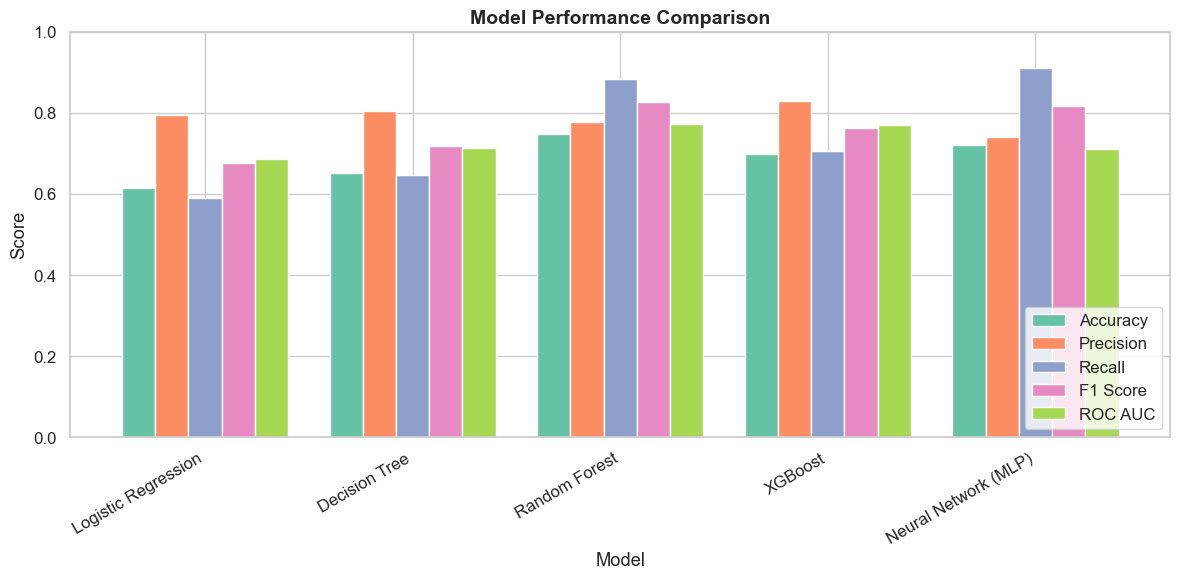

In [16]:
# Bar Chart Comparison
fig, ax = plt.subplots(figsize=(12, 6))
comp_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

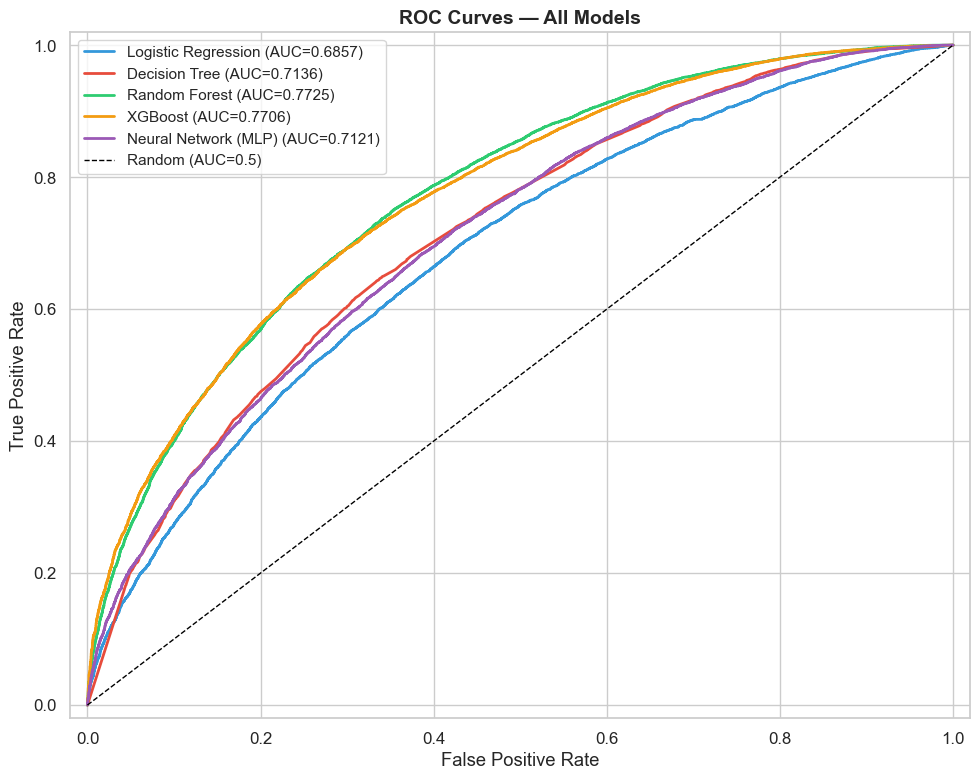

In [17]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for (name, (_, y_prob)), color in zip(models_info.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=11)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Best model by F1: Random Forest


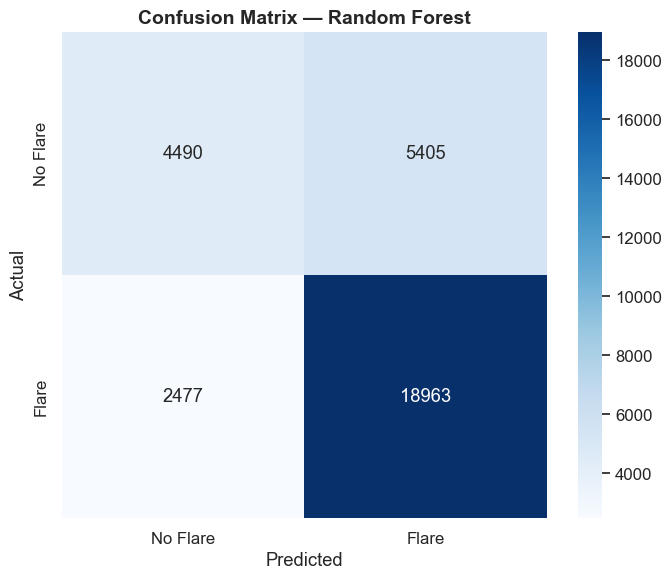

In [18]:
# Confusion Matrix for Best Model
best_model_name = comp_df['F1 Score'].idxmax()
best_pred = models_info[best_model_name][0]
print(f'Best model by F1: {best_model_name}')

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Flare', 'Flare'], yticklabels=['No Flare', 'Flare'])
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 3: Explainability with SHAP (10 pts)

We use SHAP (SHapley Additive exPlanations) on the best tree-based model to understand which features drive predictions.

In [19]:
# SHAP Analysis on XGBoost (best tree-based model)
# Use XGBoost regardless of which model scored highest, since SHAP TreeExplainer is most reliable
explainer = shap.TreeExplainer(xgb_best)

# Compute SHAP values on test set (sample for speed)
shap_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

# Clean feature names for display
clean_names = [c.replace('food_', '').replace('treat_', 'Tx:').replace('tag_', 'Tag:').replace('weather_', 'W:').replace('foodcat_', 'Cat:').replace('_', ' ').title() for c in feature_cols]
shap_sample_display = shap_sample.copy()
shap_sample_display.columns = clean_names

print(f'SHAP values computed for {len(shap_sample)} samples')

SHAP values computed for 2000 samples


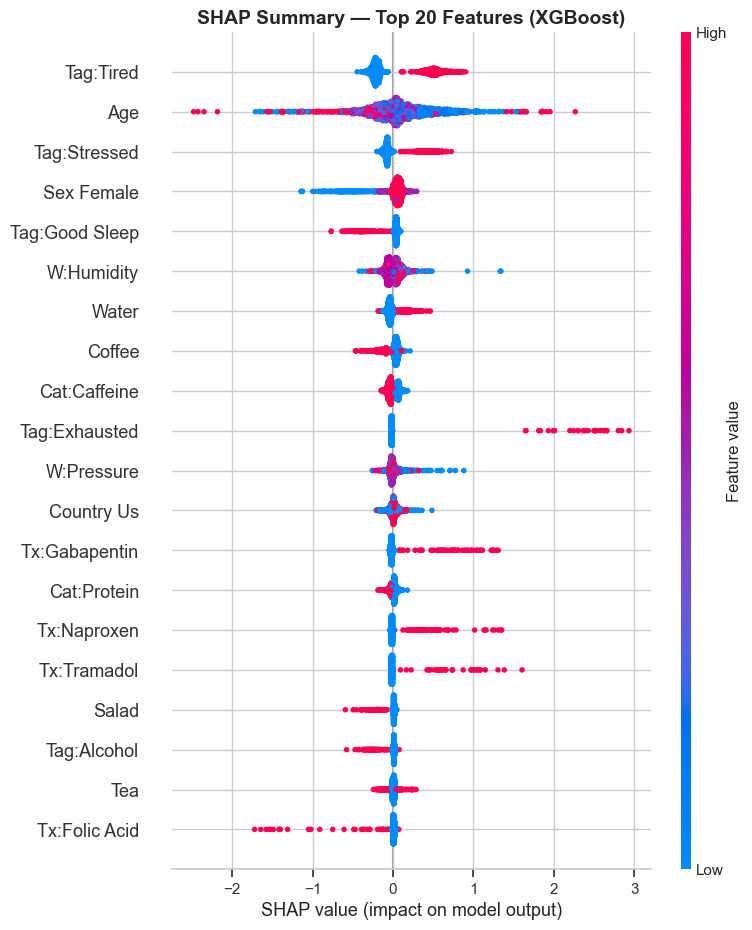

In [20]:
# SHAP Summary Plot (Beeswarm)
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values, shap_sample_display, max_display=20, show=False)
plt.title('SHAP Summary — Top 20 Features (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

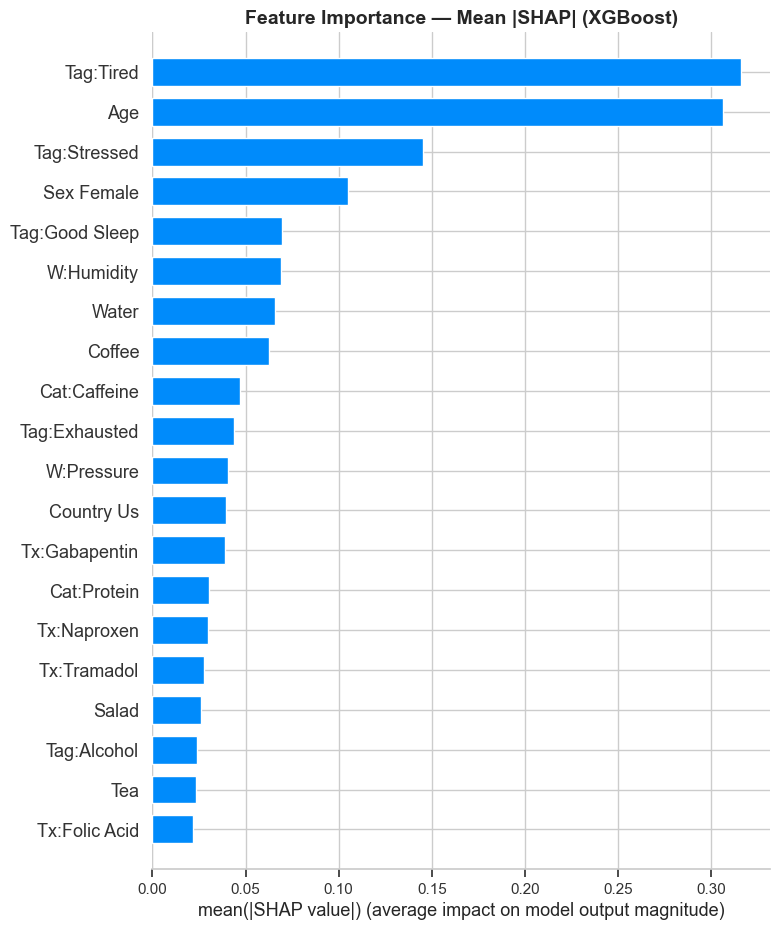

In [21]:
# SHAP Bar Plot (Mean Absolute SHAP Values)
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, shap_sample_display, plot_type='bar', max_display=20, show=False)
plt.title('Feature Importance — Mean |SHAP| (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

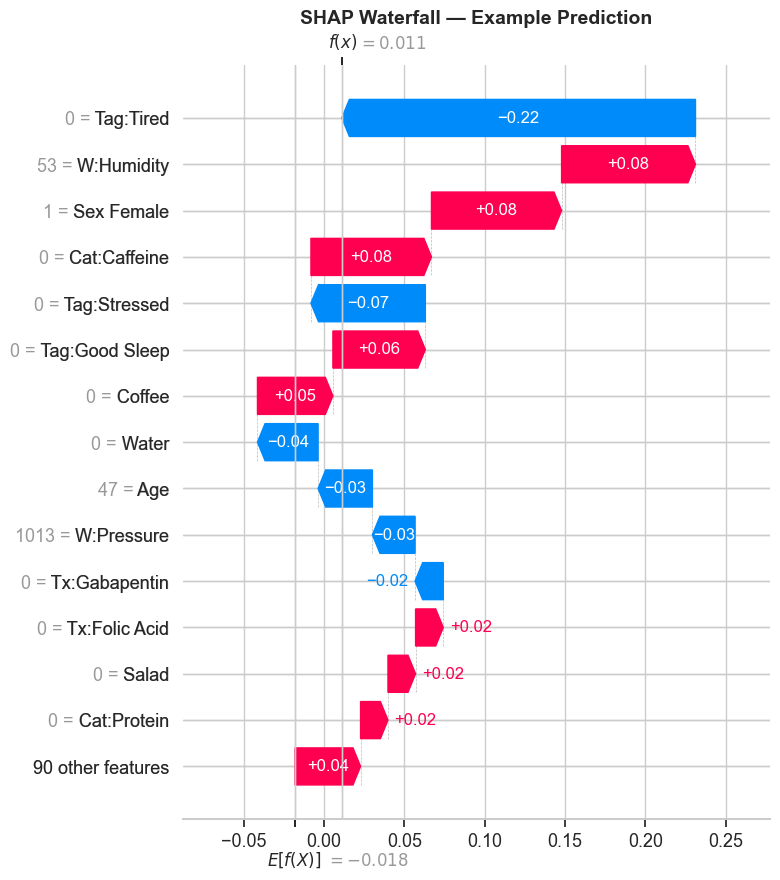

In [22]:
# SHAP Waterfall Plot — Single Prediction Example
# Pick a flare=1 example from test set
flare_indices = y_test[y_test == 1].index
sample_idx = shap_sample.index[0]

explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=shap_sample_display.iloc[0],
    feature_names=clean_names
)

fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title('SHAP Waterfall — Example Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretation

### Important Limitations

Before interpreting results, it is critical to understand what this analysis **can and cannot** tell us:

1. **Correlation, not causation.** This is observational self-reported data. We cannot conclude that any food *causes* flares — only that associations exist in the tracking data.
2. **Food is ONE factor among many.** Flares are influenced by stress, sleep quality, physical activity, weather, medication adherence, hormonal cycles, and countless other variables. Isolating the effect of a single food is inherently difficult.
3. **Small sample sizes per food.** Most foods are tracked by only 50–500 users with enough data for within-user comparison. This limits statistical power and generalizability.
4. **Self-reporting bias.** Users may be more likely to track food on "bad" days when they're trying to identify triggers, or may forget to log foods on days they feel fine.
5. **Simpson's Paradox was present.** Our initial naive analysis showed alcohol and milk as "protective" and veggies as "harmful" — results driven entirely by *who* tracks what, not the food itself. The within-user paired analysis corrects for this, but other confounders likely remain.

### Key Findings from SHAP Analysis

- The SHAP model considers **all features simultaneously** (foods, treatments, tags, weather, demographics), which partially controls for confounders
- Tags like stress, sleep quality, and exhaustion tend to be among the strongest predictors — reinforcing that **non-food factors are critical**
- Individual food features generally have small SHAP values, consistent with the finding that food alone has limited predictive power for flares
- The model's predictive accuracy (~77% AUC) comes primarily from the **combination** of all features, not any single food

### Practical Takeaways for Chronic Illness Patients
1. **Track consistently** — the more data you have, the better you can identify *your own* patterns
2. **Don't over-interpret any single food** — the effect sizes are small and individual responses vary enormously
3. **Pay equal attention to non-food factors** — stress management, sleep hygiene, and treatment adherence likely matter more than any individual food choice
4. **Discuss dietary changes with your healthcare provider** — data-driven insights are a starting point for conversation, not a prescription

In [23]:
# Save SHAP values for Streamlit app
np.save(DATA_DIR / 'shap_values.npy', shap_values)
shap_sample.to_parquet(DATA_DIR / 'shap_sample.parquet')
np.save(DATA_DIR / 'shap_expected_value.npy', np.array([explainer.expected_value]))
print('SHAP data saved for Streamlit app.')
print('\n=== ANALYSIS COMPLETE ===')

SHAP data saved for Streamlit app.

=== ANALYSIS COMPLETE ===
